<a href="https://colab.research.google.com/github/ranenshlomo/EDA_Assignment_2_Ranen_Shlomo/blob/main/Homework2_Ranen_Shlomo_318842184.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression and Classification: Error Analysis

**Student:** רנן שלמה  
**ID:** 318842184  
**Date:** 05/09/2026
**Dataset:** Real Estate Housing Dataset

## Setup and K-Fold Justification

All analyses in this assignment are conducted using k-fold cross-validation.

**Justification for k = 5:**  
The dataset contains 1,460 real-estate observations. We chose k = 5 because it provides a good balance between the bias-variance trade-off and computational cost. In every fold, approximately 80% of the data is used for training and 20% for validation, providing sufficiently large training sets while still producing reliable validation estimates.

For regression, 5-fold cross-validation is used. For classification, Stratified 5-fold cross-validation is used in order to maintain the class proportions in each fold.

In [7]:
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_fscore_support,
    matthews_corrcoef
)

from scipy.stats import skew, kurtosis

# Automatically detect the uploaded CSV file
csv_files = [
    filename for filename in uploaded.keys()
    if filename.lower().endswith('.csv')
]

if len(csv_files) == 0:
    raise ValueError("Please upload a CSV file.")

filename = csv_files[0]

# Load dataset
df = pd.read_csv(filename)

print("Loaded file:", filename)
print("Dataset shape:", df.shape)

display(df.head())

# Selected features
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'YearBuilt'
]

# Regression data
X_reg = df[features].copy()
y_reg = df['SalePrice'].copy()

# Classification data
median_price = df['SalePrice'].median()

X_clf = df[features].copy()

y_clf = (
    df['SalePrice'] > median_price
).astype(int)

print(f"\nMedian Sale Price: ${median_price:,.0f}")

print("\nClassification distribution:")
print(y_clf.value_counts())

# Cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Saving Real_Estate.csv to Real_Estate (2).csv
Loaded file: Real_Estate (2).csv
Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Median Sale Price: $163,000

Classification distribution:
SalePrice
0    732
1    728
Name: count, dtype: int64


# 1. Regression Error Analysis & Modeling

**Target Variable:** House Sale Price (`SalePrice`)

**Features:** Overall Quality, Above-Ground Living Area, Garage Capacity, Total Basement Area, and Year Built.

Three regression models are compared:

1. **Linear Regression** – baseline model.
2. **Decision Tree Regressor** – non-linear model.
3. **Random Forest Regressor** – ensemble model.

All three models use the same feature set and are evaluated using 5-fold cross-validation for a fair comparison.

,MSE,RMSE,MAE,R2
Linear Regression,1.596521e+09,39956.483,24957.224,0.747
Decision Tree,1.949653e+09,44154.879,27303.104,0.691
Random Forest,1.273318e+09,35683.586,20880.258,0.798


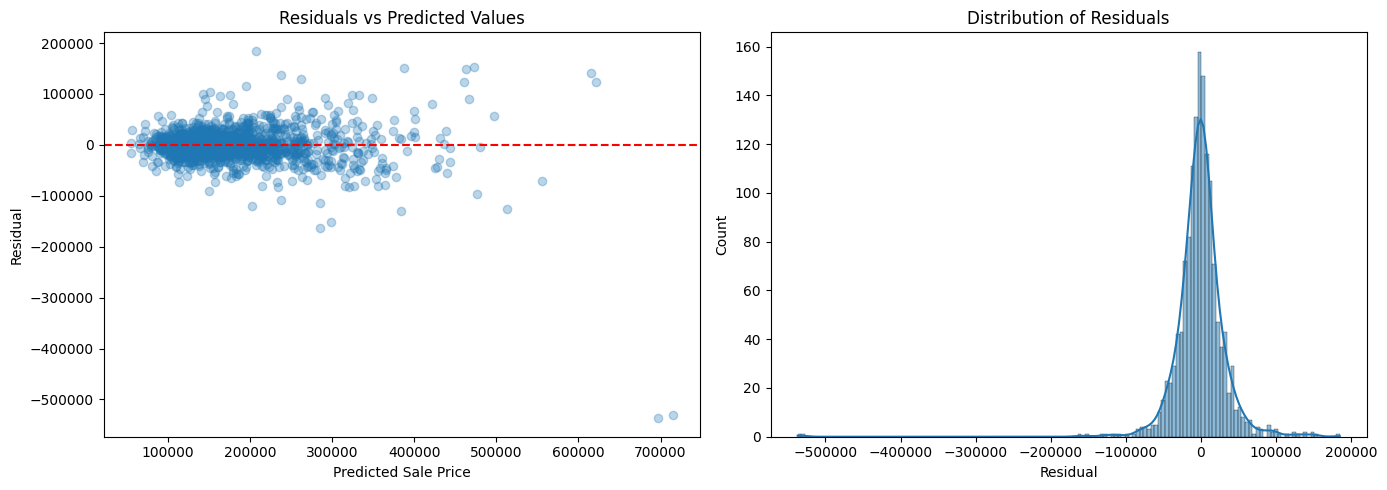


--- Statistical Properties of Errors ---

Linear Regression:
RMSE: 39,956.48
R2: 0.747
MAE: 24,957.22
Residual STD: 39,956.42
Skewness: -1.40
Kurtosis: 43.12

Decision Tree:
RMSE: 44,154.88
R2: 0.691
MAE: 27,303.10
Residual STD: 44,151.05
Skewness: -2.83
Kurtosis: 40.05

Random Forest:
RMSE: 35,683.59
R2: 0.798
MAE: 20,880.26
Residual STD: 35,678.81
Skewness: -4.26
Kurtosis: 69.36


In [8]:
# Define regression models
models_reg = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=100
    )
}

results_reg = {}

# Train and evaluate using 5-fold CV
for name, model in models_reg.items():

    y_pred = cross_val_predict(
        model,
        X_reg,
        y_reg,
        cv=kf
    )

    residuals = y_reg.to_numpy() - y_pred

    mse = mean_squared_error(
        y_reg,
        y_pred
    )

    results_reg[name] = {
        'y_pred': y_pred,
        'residuals': residuals,
        'mse': mse,
        'rmse': np.sqrt(mse),
        'mae': mean_absolute_error(
            y_reg,
            y_pred
        ),
        'r2': r2_score(
            y_reg,
            y_pred
        ),
        'std': np.std(residuals),
        'skew': skew(residuals),
        'kurtosis': kurtosis(residuals)
    }

# Model comparison table
comparison = pd.DataFrame({
    name: {
        'MSE': values['mse'],
        'RMSE': values['rmse'],
        'MAE': values['mae'],
        'R2': values['r2']
    }
    for name, values in results_reg.items()
}).T

display(comparison.round(3))

# Best model for detailed error analysis
best_model_name = "Random Forest"

preds = results_reg[best_model_name]['y_pred']
res = results_reg[best_model_name]['residuals']
abs_res = np.abs(res)

# Residual Analysis
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

ax1.scatter(
    preds,
    res,
    alpha=0.3
)

ax1.axhline(
    0,
    linestyle='--',
    color='red'
)

ax1.set_xlabel('Predicted Sale Price')
ax1.set_ylabel('Residual')
ax1.set_title('Residuals vs Predicted Values')

sns.histplot(
    res,
    kde=True,
    ax=ax2
)

ax2.set_xlabel('Residual')
ax2.set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

# Statistical properties
print("\n--- Statistical Properties of Errors ---")

for name, values in results_reg.items():

    print(f"\n{name}:")

    print(
        f"RMSE: {values['rmse']:,.2f}"
    )

    print(
        f"R2: {values['r2']:.3f}"
    )

    print(
        f"MAE: {values['mae']:,.2f}"
    )

    print(
        f"Residual STD: {values['std']:,.2f}"
    )

    print(
        f"Skewness: {values['skew']:.2f}"
    )

    print(
        f"Kurtosis: {values['kurtosis']:.2f}"
    )

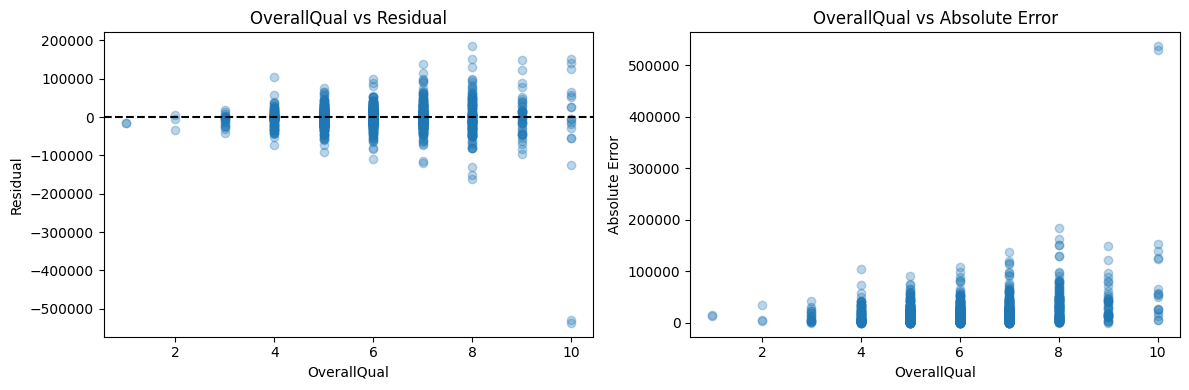

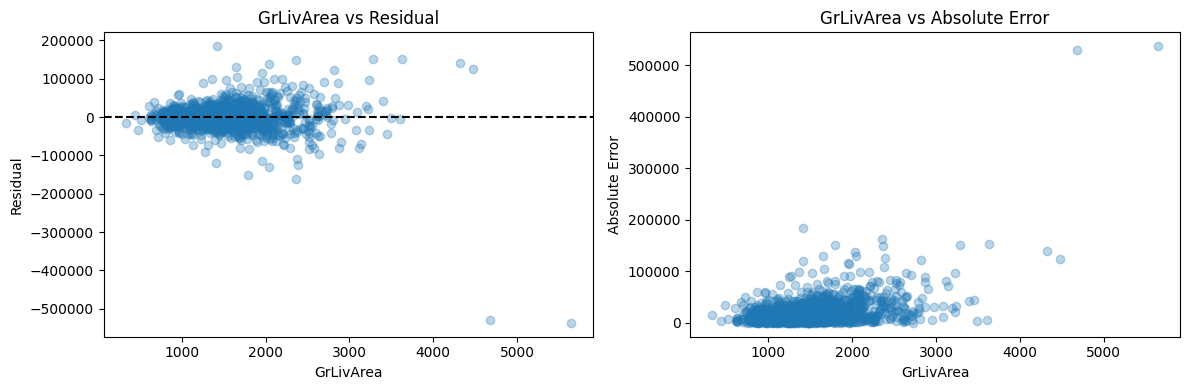

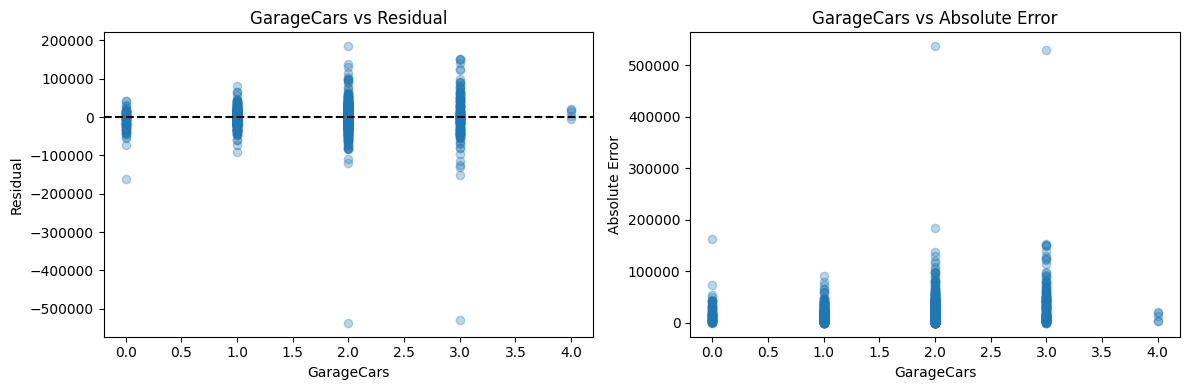

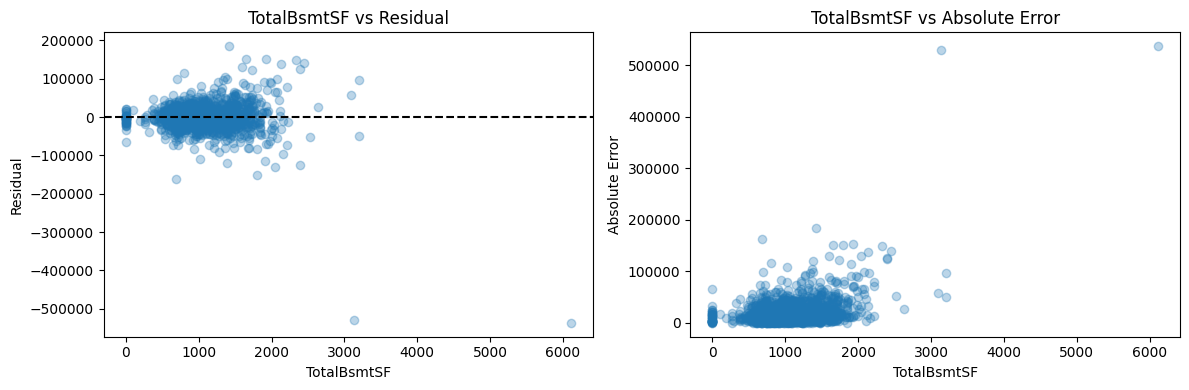

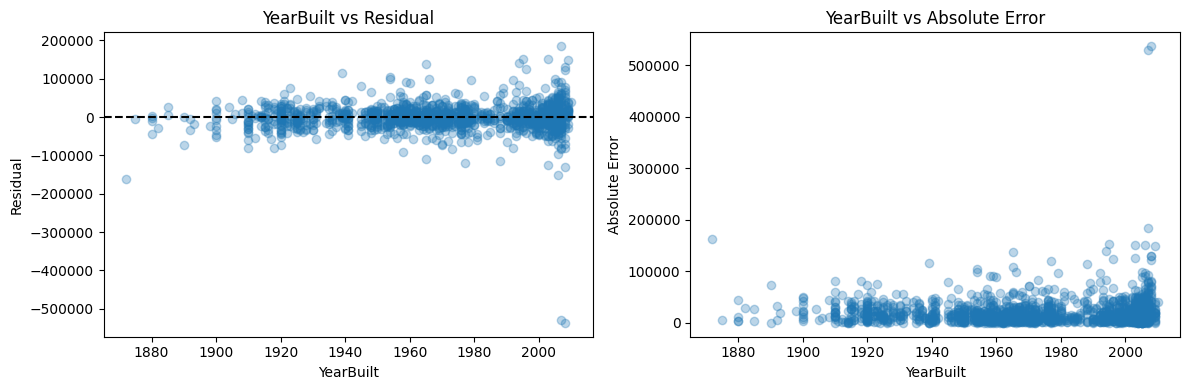

--- Top 5% Extreme Errors ---
Number of extreme cases: 73


,SalePrice,PredictedPrice,AbsoluteError,Neighborhood,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt
1298,160000,697008.64,537008.64,Edwards,10,5642,2,6110,2008
523,184750,714777.80,530027.80,Edwards,10,4676,3,3138,2007
688,392000,207107.12,184892.88,StoneBr,8,1419,2,1419,2007
1349,122000,284813.00,162813.00,OldTown,8,2358,0,684,1872
1169,625000,472384.80,152615.20,NoRidge,10,3627,3,1930,1995
1324,147000,298317.95,151317.95,Somerst,8,1795,3,1795,2006
769,538000,387090.63,150909.37,StoneBr,8,3279,3,1650,2003
898,611657,463136.00,148521.00,NridgHt,9,2364,3,2330,2009
691,755000,614822.50,140177.50,NoRidge,10,4316,3,2444,1994
313,375000,237633.80,137366.20,Timber,7,2036,2,2136,1965



--- Neighborhoods with Highest Average Error ---


,AbsoluteError
Neighborhood,
StoneBr,45004.61
NoRidge,39576.72
ClearCr,36872.80
Crawfor,34562.29
NridgHt,33165.41
Timber,29669.07
Veenker,28355.11
Edwards,27581.21
Blmngtn,23177.10


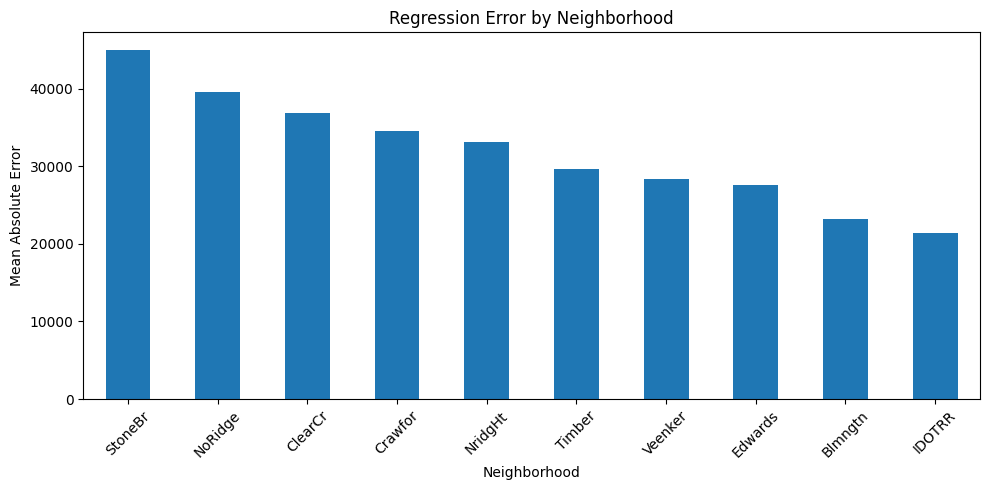

In [9]:
# 1.2 Error as a Function of Features

for feature in features:

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    ax1.scatter(
        X_reg[feature],
        res,
        alpha=0.3
    )

    ax1.axhline(
        0,
        linestyle='--',
        color='black'
    )

    ax1.set_xlabel(feature)
    ax1.set_ylabel('Residual')
    ax1.set_title(
        f'{feature} vs Residual'
    )

    ax2.scatter(
        X_reg[feature],
        abs_res,
        alpha=0.3
    )

    ax2.set_xlabel(feature)
    ax2.set_ylabel('Absolute Error')
    ax2.set_title(
        f'{feature} vs Absolute Error'
    )

    plt.tight_layout()
    plt.show()


# Create error analysis dataframe
error_df = df.copy()

error_df['PredictedPrice'] = preds
error_df['Residual'] = res
error_df['AbsoluteError'] = abs_res


# 1.3 Top 5% Extreme Errors

threshold_95 = np.percentile(
    abs_res,
    95
)

extreme_cases = error_df[
    error_df['AbsoluteError'] > threshold_95
].sort_values(
    'AbsoluteError',
    ascending=False
)

print("--- Top 5% Extreme Errors ---")

print(
    "Number of extreme cases:",
    len(extreme_cases)
)

display(
    extreme_cases[
        [
            'SalePrice',
            'PredictedPrice',
            'AbsoluteError',
            'Neighborhood',
            'OverallQual',
            'GrLivArea',
            'GarageCars',
            'TotalBsmtSF',
            'YearBuilt'
        ]
    ].head(10).round(2)
)


# Neighborhood / Sector Error Analysis

neighborhood_error = (
    error_df
    .groupby('Neighborhood')['AbsoluteError']
    .mean()
    .sort_values(ascending=False)
)

print(
    "\n--- Neighborhoods with Highest Average Error ---"
)

display(
    neighborhood_error
    .head(10)
    .round(2)
)

plt.figure(
    figsize=(10, 5)
)

neighborhood_error.head(10).plot(
    kind='bar'
)

plt.ylabel('Mean Absolute Error')
plt.xlabel('Neighborhood')

plt.title(
    'Regression Error by Neighborhood'
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Regression Discussion

- **Residual Analysis:** The residuals are generally centered around zero. However, the error spread becomes larger for several expensive and unusual properties, indicating some heteroscedasticity. This means that the variance of the prediction error is not completely constant.

- **Feature Error Analysis:** Properties with unusually large living areas, basement areas, or high quality values tend to show greater variation in prediction error. These properties are less common and are therefore harder for the model to predict accurately.

- **Extreme Errors:** The top 5% largest absolute errors mainly correspond to rare or exceptional properties rather than obvious data-quality problems. This suggests that both unusual properties and model limitations contribute to the largest errors.

- **Neighborhood Analysis:** Some neighborhoods have considerably higher mean prediction errors than others. This indicates that location-specific effects influence house prices and are not fully captured by the five numerical features used by the regression models.

- **Statistical Properties:** The residual distribution has high kurtosis, indicating heavy tails and the presence of several extreme errors. The residuals also show negative skewness, meaning that some large overpredictions affect the distribution.

- **Model Comparison:** Random Forest achieved the best regression performance, with approximately RMSE = 35,684, MAE = 20,880 and R² = 0.798. Linear Regression performed reasonably well as a baseline, but cannot capture all non-linear relationships. The individual Decision Tree has higher variance and performs worse than the Random Forest ensemble.

Random Forest is therefore the preferred regression model because it provides the best predictive performance and captures non-linear interactions between property characteristics. Its main disadvantage is lower interpretability compared with Linear Regression.

# 2. Classification Error Analysis

**Target Variable:** `HighPrice`

The original dataset contains a continuous sale-price target and does not contain a natural binary classification target.

Therefore:

- **HighPrice = 1** if the sale price is above the median.
- **HighPrice = 0** if the sale price is equal to or below the median.

The median sale price is **$163,000**.

This produces an almost perfectly balanced classification problem, with approximately half of the properties in each class.

The same five structural features are used for classification. `SalePrice` itself is excluded from the input features in order to avoid data leakage.

A Random Forest Classifier is used for the detailed error analysis.

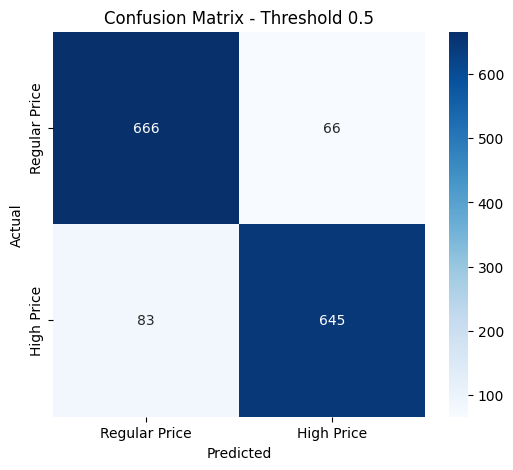

               precision    recall  f1-score   support

Regular Price       0.89      0.91      0.90       732
   High Price       0.91      0.89      0.90       728

     accuracy                           0.90      1460
    macro avg       0.90      0.90      0.90      1460
 weighted avg       0.90      0.90      0.90      1460



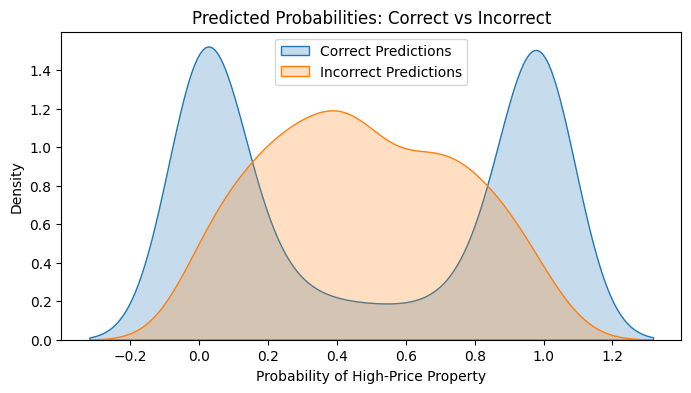

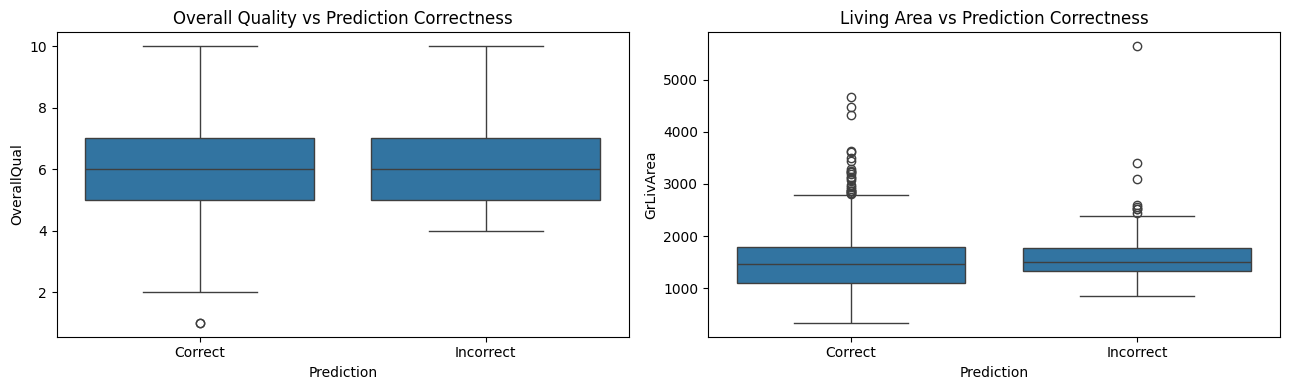

In [10]:
# Random Forest Classifier

clf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

# Cross-validated predicted probabilities
y_prob = cross_val_predict(
    clf,
    X_clf,
    y_clf,
    cv=skf,
    method='predict_proba'
)[:, 1]

# Default threshold
y_pred_clf = (
    y_prob >= 0.5
).astype(int)


# 2.1 Confusion Matrix

cm = confusion_matrix(
    y_clf,
    y_pred_clf
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Regular Price',
        'High Price'
    ],
    yticklabels=[
        'Regular Price',
        'High Price'
    ]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title(
    'Confusion Matrix - Threshold 0.5'
)

plt.show()

print(
    classification_report(
        y_clf,
        y_pred_clf,
        target_names=[
            'Regular Price',
            'High Price'
        ]
    )
)


# 2.2 Probability-Based Analysis

correct = (
    y_clf.to_numpy()
    == y_pred_clf
)

incorrect = ~correct

plt.figure(
    figsize=(8, 4)
)

sns.kdeplot(
    y_prob[correct],
    label='Correct Predictions',
    fill=True
)

sns.kdeplot(
    y_prob[incorrect],
    label='Incorrect Predictions',
    fill=True
)

plt.xlabel(
    'Probability of High-Price Property'
)

plt.title(
    'Predicted Probabilities: Correct vs Incorrect'
)

plt.legend()
plt.show()


# 2.3 Error as a Function of Features

classification_df = X_clf.copy()

classification_df['Prediction'] = np.where(
    correct,
    'Correct',
    'Incorrect'
)

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

sns.boxplot(
    data=classification_df,
    x='Prediction',
    y='OverallQual',
    ax=ax1
)

ax1.set_title(
    'Overall Quality vs Prediction Correctness'
)

sns.boxplot(
    data=classification_df,
    x='Prediction',
    y='GrLivArea',
    ax=ax2
)

ax2.set_title(
    'Living Area vs Prediction Correctness'
)

plt.tight_layout()
plt.show()

,Threshold,Precision,Recall,F1,F-Beta (Beta=2),MCC
0,0.1,0.752,0.981,0.851,0.924,0.690
1,0.2,0.813,0.963,0.882,0.929,0.755
2,0.3,0.856,0.937,0.894,0.919,0.783
3,0.4,0.880,0.916,0.898,0.909,0.792
4,0.5,0.907,0.886,0.896,0.890,0.796
5,0.6,0.921,0.850,0.884,0.864,0.780
6,0.7,0.943,0.823,0.879,0.844,0.780
7,0.8,0.961,0.777,0.860,0.808,0.760
8,0.9,0.981,0.694,0.813,0.737,0.712


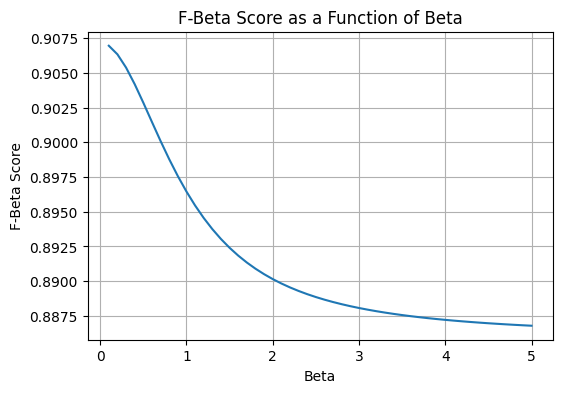

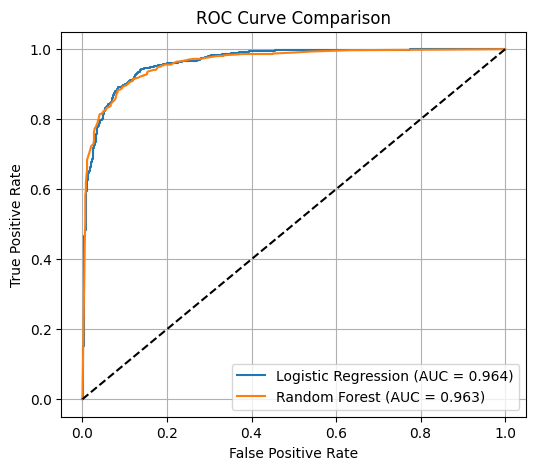

In [11]:
# 2.4 Threshold Sensitivity Analysis

thresholds = np.arange(
    0.1,
    1.0,
    0.1
)

threshold_results = []

beta = 2

for threshold in thresholds:

    pred_t = (
        y_prob >= threshold
    ).astype(int)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_clf,
            pred_t,
            average='binary',
            zero_division=0
        )
    )

    denominator = (
        beta**2 * precision
        + recall
    )

    if denominator > 0:

        f_beta = (
            (1 + beta**2)
            * precision
            * recall
        ) / denominator

    else:
        f_beta = 0

    mcc = matthews_corrcoef(
        y_clf,
        pred_t
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F-Beta (Beta=2)': f_beta,
        'MCC': mcc
    })

df_thresholds = pd.DataFrame(
    threshold_results
)

display(
    df_thresholds.round(3)
)


# F-Beta as a Function of Beta

betas = np.linspace(
    0.1,
    5,
    50
)

pred_fixed = (
    y_prob >= 0.5
).astype(int)

p_fixed, r_fixed, _, _ = (
    precision_recall_fscore_support(
        y_clf,
        pred_fixed,
        average='binary',
        zero_division=0
    )
)

f_beta_values = []

for b in betas:

    denominator = (
        b**2 * p_fixed
        + r_fixed
    )

    if denominator > 0:

        score = (
            (1 + b**2)
            * p_fixed
            * r_fixed
        ) / denominator

    else:
        score = 0

    f_beta_values.append(
        score
    )

plt.figure(
    figsize=(6, 4)
)

plt.plot(
    betas,
    f_beta_values
)

plt.xlabel('Beta')
plt.ylabel('F-Beta Score')

plt.title(
    'F-Beta Score as a Function of Beta'
)

plt.grid()
plt.show()


# ROC and AUC Model Comparison

logistic_model = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'model',
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

models_clf = {

    "Logistic Regression":
        logistic_model,

    "Random Forest":
        RandomForestClassifier(
            random_state=42,
            n_estimators=100
        )
}

plt.figure(
    figsize=(6, 5)
)

for name, model in models_clf.items():

    probabilities = cross_val_predict(
        model,
        X_clf,
        y_clf,
        cv=skf,
        method='predict_proba'
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_clf,
        probabilities
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f'{name} '
            f'(AUC = {roc_auc:.3f})'
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    color='black'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve Comparison'
)

plt.legend()
plt.grid()

plt.show()

## Classification Discussion

- **Confusion Matrix:** At the standard threshold of 0.5, the Random Forest classifier correctly classifies almost 90% of the properties. False Positives are regular-price properties incorrectly classified as high-price, while False Negatives are genuinely high-price properties incorrectly classified as regular-price.

- **Critical Error:** There are slightly more False Negatives than False Positives. If the objective is to identify valuable properties, False Negatives may be considered more critical because a genuinely high-value property could be overlooked.

- **Probability and Feature Analysis:** Many incorrect predictions occur near the probability threshold of 0.5, indicating uncertainty between the two groups. The feature distributions also overlap, showing that price category cannot be perfectly determined from a small number of structural characteristics alone.

- **Threshold Sensitivity:** Lower thresholds produce higher Recall but lower Precision. Higher thresholds produce higher Precision but lower Recall. Thresholds around 0.4–0.5 provide a relatively stable balance. If missing high-price properties is considered particularly costly, a lower threshold may be preferred.

- **ROC and Model Comparison:** Both Logistic Regression and Random Forest achieve an AUC of approximately 0.96. This demonstrates strong separation between the two price groups. Logistic Regression performs slightly better in terms of AUC while also being easier to interpret, whereas Random Forest can represent more complex non-linear relationships.

- **F-Beta:** Increasing beta gives more weight to Recall. Therefore, β > 1 is useful when False Negatives are considered more important than False Positives.

# 3. Final Reflection

**1. Where does the model fail most?**  
The regression model fails mainly on rare and exceptional properties, particularly houses with unusual combinations of size, quality, location, and sale price. The neighborhood analysis also shows that some areas have considerably higher prediction errors. The classification model fails mainly on borderline properties whose characteristics overlap between the two price categories.

**2. Are failures due to data, model, or formulation?**  
The failures arise from a combination of factors. Some observations represent genuine real-world outliers rather than incorrect data. The regression models are also limited because only five structural variables are used to explain a property price that depends on many additional factors. In classification, converting a continuous sale price into two classes creates borderline observations just above and below the median that may be very similar.

**3. What improvements would you propose?**  
Regression performance could be improved by adding variables such as Neighborhood, remodeling information, kitchen quality, bathrooms, garage quality, exterior quality, and sale conditions. Hyperparameter tuning and Gradient Boosting models could also be evaluated. For classification, the threshold should be chosen according to the relative cost of False Positives and False Negatives.

**4. What insights did you gain in your analysis?**  
The analysis shows that overall performance metrics alone are not sufficient to understand model behavior. Residual and extreme-error analysis reveal where regression models fail, while confusion matrices and threshold analysis reveal the type and importance of classification errors. Random Forest performs best for regression because it captures non-linear relationships, while Logistic Regression demonstrates that a simpler and more interpretable model can still provide excellent classification performance.